<a href="https://colab.research.google.com/github/kartik24bsa10009/Group-17-A24-E21/blob/main/FDS_Grp17_GroupActivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
Step 1: Install & Import Libraries
```



In [ ]:
# Install required package
!pip install kagglehub[pandas-datasets]

# Imports
import pandas as pd
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Load Dataset

In [ ]:
file_path = "InSDN_DatasetCSV/Normal_data.csv"   # others are OVS.csv and metasploitable-2.csv

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "badcodebuilder/insdn-dataset",
    file_path
)

# Preview
df.head()

100%|██████████| 8.08M/8.08M [00:00<00:00, 66.6MB/s]

Extracting zip of Normal_data.csv...


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,185.127.17.56-192.168.20.133-443-53648-6,185.127.17.56,443,192.168.20.133,53648,6,5/2/2020 13:58,245230,44,40,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
1,185.127.17.56-192.168.20.133-443-53650-6,192.168.20.133,53650,185.127.17.56,443,6,5/2/2020 13:58,1605449,107,149,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
2,192.168.20.133-192.168.20.2-35108-53-6,192.168.20.133,35108,192.168.20.2,53,6,5/2/2020 13:58,53078,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
3,192.168.20.133-192.168.20.2-35108-53-6,192.168.20.2,53,192.168.20.133,35108,6,5/2/2020 13:58,6975,1,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
4,154.59.122.74-192.168.20.133-443-60900-6,192.168.20.133,60900,154.59.122.74,443,6,5/2/2020 13:58,190141,13,16,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal


Step 3: Basic Data Understanding

In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.info()

# Statistical summary
df.describe()

Shape: (68424, 84)

Columns:
 Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',


,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,68424.000000,68424.000000,68424.000000,6.842400e+04,68424.000000,68424.000000,6.842400e+04,6.842400e+04,68424.000000,68424.000000,...,68424.000000,68424.0,6.842400e+04,6.842400e+04,6.842400e+04,6.842400e+04,6.842400e+04,6.842400e+04,6.842400e+04,6.842400e+04
mean,37361.032459,9733.738557,11.418947,1.362636e+07,11.807217,18.592628,3.354497e+03,4.128116e+04,425.863644,22.297469,...,3.891266,0.0,1.887697e+05,1.434025e+05,3.980718e+05,8.563484e+04,4.508770e+06,6.041184e+05,5.066966e+06,3.975015e+06
std,20305.851419,19352.308798,5.551915,3.360107e+07,112.712183,235.949827,1.560998e+05,7.680108e+05,1425.400448,67.228213,...,57.082340,0.0,1.373001e+06,1.105629e+06,2.467808e+06,1.027435e+06,1.314630e+07,3.486207e+06,1.448106e+07,1.246315e+07
min,0.000000,0.000000,0.000000,-1.540000e+02,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,34213.500000,53.000000,6.000000,3.134000e+03,1.000000,2.000000,3.000000e+01,1.370000e+02,30.000000,0.000000,...,1.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,43383.000000,443.000000,6.000000,4.799000e+03,1.000000,3.000000,3.600000e+01,5.020000e+02,36.000000,0.000000,...,1.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,52105.250000,443.000000,17.000000,7.122470e+05,6.000000,5.000000,5.990000e+02,7.620000e+02,249.000000,34.000000,...,3.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65513.000000,60998.000000,17.000000,1.200000e+08,16928.000000,34094.000000,3.160000e+07,1.070000e+08,64239.000000,3900.000000,...,11180.000000,0.0,1.040000e+08,6.830000e+07,1.040000e+08,1.040000e+08,1.190000e+08,7.300000e+07,1.190000e+08,1.190000e+08


Step 4: Data Cleaning

In [ ]:
# Check missing values
df.isnull().sum()

# Drop columns with too many missing values
threshold = 0.5 * len(df)
df = df.dropna(thresh=threshold, axis=1)

# Fill numeric missing values
df.fillna(df.mean(numeric_only=True))

# Fill categorical missing values
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0])

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

Step 5: Feature Engineering

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

Step 6: Data Processing Cycle (Train-Test Split)

In [ ]:
from sklearn.model_selection import train_test_split

# 'target' is actual column name from the db
target_column = 'Label'

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (9242, 83)
Test shape: (2311, 83)


Step 7: Visualization

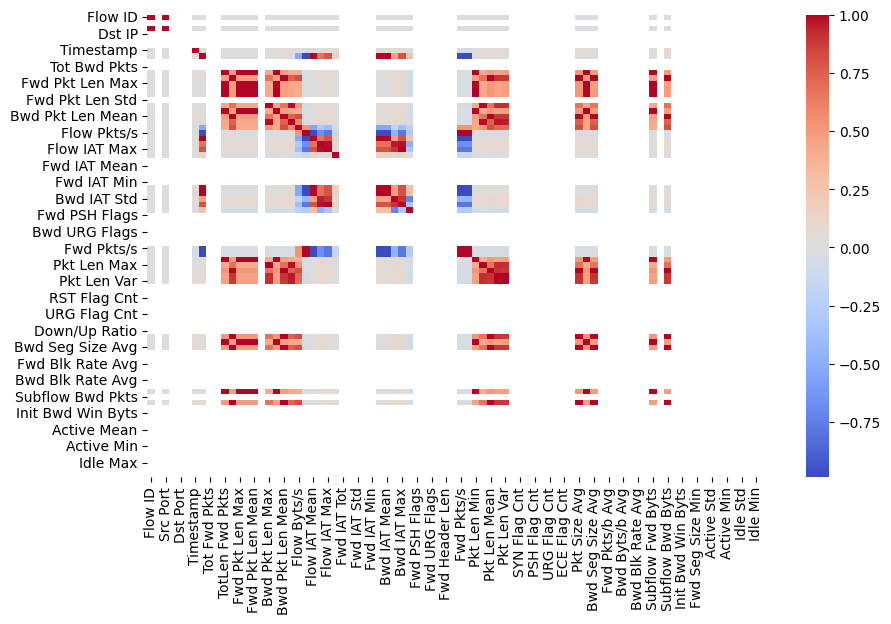

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

Step 8: Save Cleaned Dataset

In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)



---
# Analysis


1. PCA (Dimensionality Reduction)

In [ ]:
from sklearn.decomposition import PCA

# Separate features and target
X = df.drop(columns=[target_column])
y = df[target_column]

# Apply PCA
pca = PCA(n_components=2)   # reduce to 2D for visualization
X_pca = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.99891516 0.00108046]


2. K-Means Clustering

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

clusters = kmeans.labels_

# Add cluster labels to dataset
df['Cluster'] = clusters

print("Cluster Counts:\n", df['Cluster'].value_counts())

Cluster Counts:
 Cluster
1    5826
0    5727
Name: count, dtype: int64


3. Random Forest (Classification)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", rf.score(X_test, y_test))

Random Forest Accuracy: 1.0


4. ROC Curve

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Check if the model has been trained on multiple classes
if len(rf.classes_) < 2:
    print("ROC curve cannot be plotted as the target variable contains only one class.")
    print("Please check the data cleaning and preprocessing steps.")
else:
    # Probabilities for the positive class (class 1)
    y_prob = rf.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

ROC curve cannot be plotted as the target variable contains only one class.
Please check the data cleaning and preprocessing steps.


5. Confusion Matrix

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


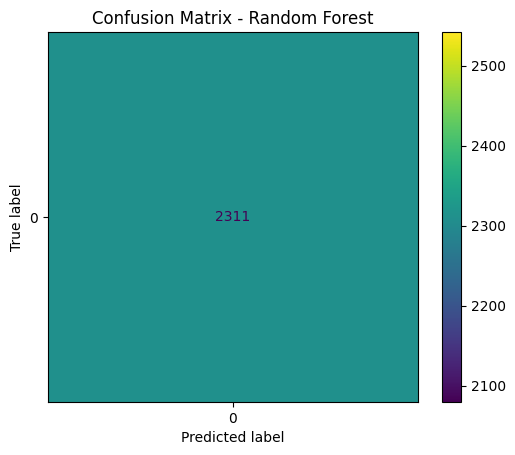

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

6. KNN (K-Nearest Neighbors)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", knn.score(X_test, y_test))

KNN Accuracy: 1.0


7. Regression Analysis

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.0
R2 Score: 1.0


PCA → reduces dimensionality & improves efficiency

K-Means → unsupervised clustering of network traffic

Random Forest → robust classification model

ROC Curve → evaluates classification performance

Confusion Matrix → shows TP, FP, TN, FN

KNN → distance-based classification

Regression → analyzes numerical relationships



---

